# Análise de Embeddings e Redução da Dimensionalidade

**Objetivo.** Dado um conjunto de textos, gerar embeddings com BERT e investigar a estrutura dos dados via PCA, t-SNE e UMAP. Em seguida, identificar clusters e relacioná-los a categorias semânticas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

In [2]:
sentences = [
    'I swap butter for olive oil in many recipes.',
    'Canberra is the capital of Australia.',
    'Ottawa is the capital city of Canada.',
    'Paris is the most populated city in France.',
    'Tokyo is among the most populous metropolitan areas worldwide.',
    'I prefer my coffee with no sugar and a splash of milk.',
    'The recipe for pasta carbonara is simple.',
    'A pinch of salt enhances sweetness in desserts.',
    'Alignment techniques reduce harmful outputs.',
    'Explainable AI highlights salient features for decisions.',
    'Transformer models enable long-range language dependencies.',
    'Black swan events stress-test portfolio resilience.',
    'The Sahara Desert spans much of North Africa.',
    'Inflation erodes real purchasing power of cash.',
    'Aromatics like garlic and onion build flavor early.',
    'Value stocks trade at lower multiples relative to fundamentals.',
    'Quantization reduces memory with minimal accuracy loss.',
    'Tax-loss harvesting offsets capital gains.',
    'Investing in technology can be risky.',
    'Fermented foods add acidity and complexity.',
    'Marinating tofu improves texture and taste.',
    'Vector databases power semantic search at scale.',
    'Distillation transfers knowledge from large to small models.',
    'The Great Barrier Reef lies off Australia’s northeast coast.',
    'Retrieval-augmented generation grounds answers in sources.',
    'Iceland lies on the Mid-Atlantic Ridge.',
    'The Baltic states border the eastern Baltic Sea.',
    'Multimodal learning aligns text with images and audio.',
    'Risk tolerance should guide position sizing.',
    'Time in the market beats timing the market.',
    'Behavioral biases can derail investment plans.',
    'Reinforcement learning fine-tunes policies from human feedback.',
    'Edge AI runs models under strict latency constraints.',
    'Deglazing lifts browned bits to make pan sauces.',
    'Tempering chocolate stabilizes cocoa butter crystals.',
    'What is the capital of France?',
    'Johannesburg is a major city but not South Africa’s capital.',
    'The Danube passes through multiple European capitals.',
    'The Amazon River carries one of the largest water volumes on Earth.',
    'A healthy emergency fund reduces forced selling.',
    'I batch-cook grains for quick lunches.',
    'Resting steak helps redistribute the juices.',
    'The Atacama is one of the driest deserts on the planet.',
    'Liquidity risk rises when trading volumes are thin.',
    'Mount Everest is the highest peak above sea level.',
    'Graph neural networks capture relational structure.',
    'Sourdough starter needs regular feedings to stay active.',
    'The stock market experienced a drop today.',
    'Umami-rich ingredients deepen savory dishes.',
    'Al dente pasta retains a slight bite after cooking.',
    'Rebalancing restores target asset allocation.',
    'Continual learning mitigates catastrophic forgetting.',
    'Bond duration measures sensitivity to interest-rate changes.',
    'Diffusion models synthesize high-fidelity images.',
    'Expense ratios compound against long-term returns.',
    'Self-supervised pretraining reduces labeled data needs.',
    'What country contains the city of Kyoto?',
    'Stir-frying requires high heat and constant movement.',
    'Covered calls generate income with capped upside.',
    'The Nile flows northward into the Mediterranean Sea.',
    'Causal inference distinguishes correlation from effect.',
    'Prompt engineering steers generative behavior reliably.',
    'Few-shot prompting improves generalization on new tasks.',
    'Growth investing prioritizes earnings expansion.',
    'The Alps stretch across several central European countries.',
    'The Andes form a continuous mountain range along South America.',
    'I cook vegetarian meals on weekdays to simplify planning.',
    'Natural language processing has advanced greatly.',
    'Sous-vide delivers precise temperature control.',
    'Diversification reduces idiosyncratic risk across holdings.',
    'Sharpe ratio evaluates risk-adjusted performance.',
    'Artificial intelligence is transforming the world.',
    'Credit spreads widen during economic uncertainty.',
    'Emerging markets add diversification but higher volatility.',
    'Mise en place speeds up weeknight cooking.',
    'The Caspian Sea is a landlocked body of water.',
    'Evaluation with benchmarks must avoid data leakage.',
    'Cairo sits along the Nile River delta.',
    'Federated learning trains models without centralizing data.',
    'Lagos is Nigeria’s largest city by population.',
    'Dollar-cost averaging smooths entry price over time.',
    'LoRA adapters enable efficient fine-tuning.',
    'I keep a jar of homemade pesto for pasta.',
    'New Delhi serves as the seat of India’s government.',
    'I like to cook Italian dishes on Sundays.',
    'Roasting vegetables caramelizes natural sugars.',
    'ETFs provide broad market exposure with intraday liquidity.',
    'Proofing time affects a bread’s crumb structure.'
    ]


## Predição dos Embeddings

Utilize o modelo BERT pré-treinado para gerar embeddings de todos os textos fornecidos.  
O objetivo é obter uma matriz `X` com formato **(N, dim)**, onde **N** é o número de textos e **dim** é a dimensionalidade dos vetores de embedding.

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch

# Carrega o modelo BERT pré-treinado (base, inglês)
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

def get_bert_embedding(texts, tokenizer, model, batch_size=16):
    """
    Gera embeddings usando o token [CLS] do BERT.
    O vetor [CLS] (posição 0 na sequência) agrega o significado
    de toda a sentença após o pré-treinamento com NSP (Next Sentence Prediction).
    """
    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors='pt'
            )
            outputs = model(**encoded)
            # last_hidden_state shape: (batch, seq_len, 768)
            # Seleciona apenas o token [CLS] → (batch, 768)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.numpy())
    return np.vstack(all_embeddings)

print(f"Gerando embeddings para {len(sentences)} sentenças...")
X = get_bert_embedding(sentences, tokenizer, model)

print(f"Shape da matriz de embeddings: {X.shape}")
print(f"  → {X.shape[0]} textos  |  {X.shape[1]} dimensões por embedding")

# Normalização L2: favorece similaridade de cosseno nas comparações
X_norm = normalize(X, norm='l2')
print("Embeddings normalizados (L2) prontos para redução de dimensionalidade.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings para 88 sentenças...
Shape da matriz de embeddings: (88, 768)
  → 88 textos  |  768 dimensões por embedding
Embeddings normalizados (L2) prontos para redução de dimensionalidade.


## PCA

Aplique **PCA (Principal Component Analysis)** para projetar os embeddings em duas dimensões e visualizar a estrutura global dos dados.  
O PCA ajuda a capturar as direções de maior variância e pode indicar agrupamentos lineares.

**Tarefas:**
- Reduza a dimensionalidade dos embeddings para 2 componentes principais.  
- Plote os pontos resultantes com `matplotlib`, identificando possíveis agrupamentos.  
- Analise qualitativamente se há separação entre textos de temas distintos.

Variância explicada — PC1: 18.87% | PC2: 10.37% | Total: 29.24%


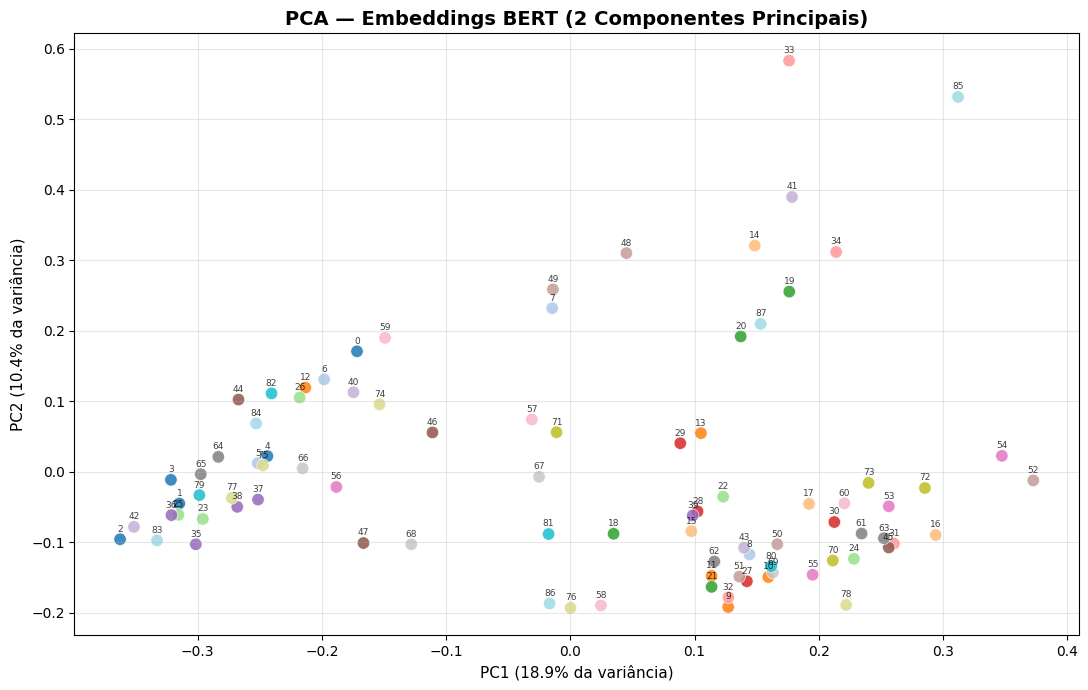


Análise: O PCA projeta os embeddings nas direções de maior variância global.
Grupos temáticos distintos (culinária, finanças, IA, geografia) tendem a se
separar no espaço 2D, embora a projeção linear não revele estruturas não-lineares.


In [4]:
# ── PCA: redução para 2 componentes principais ──────────────────────────────

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_norm)

var = pca.explained_variance_ratio_
print(f"Variância explicada — PC1: {var[0]:.2%} | PC2: {var[1]:.2%} | Total: {sum(var):.2%}")

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c=np.arange(len(sentences)), cmap='tab20',
           s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
for i, (x, y) in enumerate(X_pca):
    ax.annotate(str(i), (x, y), fontsize=6.5, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points', alpha=0.75)

ax.set_title('PCA — Embeddings BERT (2 Componentes Principais)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({var[0]:.1%} da variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]:.1%} da variância)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnálise: O PCA projeta os embeddings nas direções de maior variância global.")
print("Grupos temáticos distintos (culinária, finanças, IA, geografia) tendem a se")
print("separar no espaço 2D, embora a projeção linear não revele estruturas não-lineares.")

## t-SNE

Use **t-SNE (t-distributed Stochastic Neighbor Embedding)** para investigar a estrutura local dos dados.  
Diferente do PCA, o t-SNE tenta preservar vizinhanças locais e pode revelar grupos mais sutis.

**Tarefas:**
- Reduza os embeddings para 2D usando `TSNE` do `scikit-learn`.  
- Ajuste parâmetros como `perplexity` e `learning_rate` para comparar resultados.  
- Visualize o mapa e observe se os textos semelhantes ficam próximos.

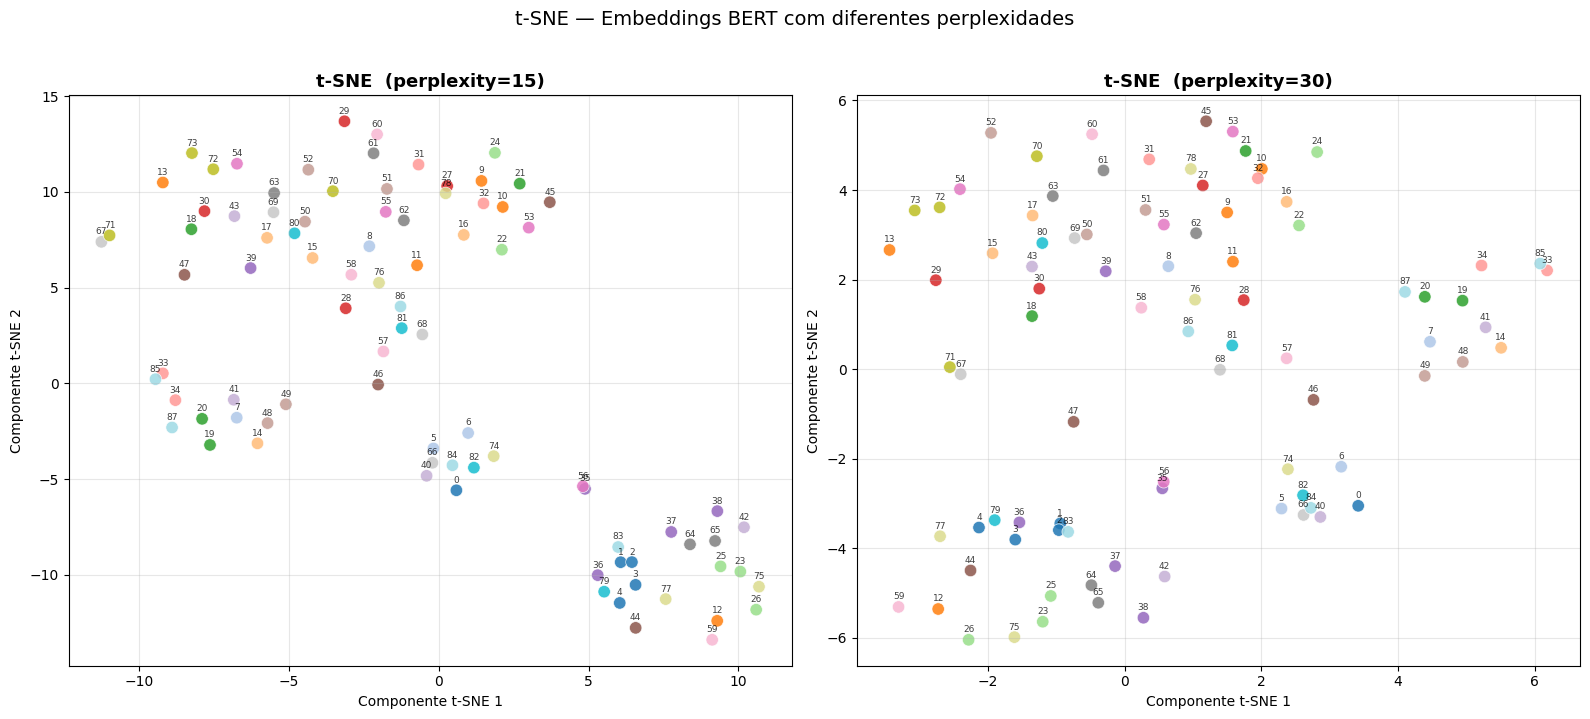

Análise: perplexidade menor → clusters mais compactos e isolados.
Perplexidade maior → estrutura mais contínua; relações entre clusters emergem.


In [5]:
# ── t-SNE: exploração da estrutura local ────────────────────────────────────
# Testamos dois valores de perplexidade para comparar o impacto no layout.
# Perplexidade ≈ número efetivo de vizinhos considerados; valores típicos: 5–50.

perplexities = [15, 30]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate='auto',
        init='pca',       # inicialização com PCA reduz instabilidade
        n_iter=1000,
        random_state=42
    )
    X_tsne_tmp = tsne.fit_transform(X_norm)
    ax.scatter(X_tsne_tmp[:, 0], X_tsne_tmp[:, 1],
               c=np.arange(len(sentences)), cmap='tab20',
               s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
    for i, (x, y) in enumerate(X_tsne_tmp):
        ax.annotate(str(i), (x, y), fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points', alpha=0.75)
    ax.set_title(f't-SNE  (perplexity={perp})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Componente t-SNE 1', fontsize=10)
    ax.set_ylabel('Componente t-SNE 2', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE — Embeddings BERT com diferentes perplexidades', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Versão final (perplexity=30) para usar na comparação posterior
tsne_final = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                  init='pca', n_iter=1000, random_state=42)
X_tsne_final = tsne_final.fit_transform(X_norm)

print("Análise: perplexidade menor → clusters mais compactos e isolados.")
print("Perplexidade maior → estrutura mais contínua; relações entre clusters emergem.")

## UMAP

Aplique **UMAP (Uniform Manifold Approximation and Projection)** como alternativa ao t-SNE.  
O UMAP é mais eficiente, preserva parte da estrutura global e é útil para visualização e pré-processamento.

**Tarefas:**
- Gere uma projeção 2D dos embeddings com `umap.UMAP`.  
- Experimente variar `n_neighbors` e `min_dist` para observar mudanças na distribuição dos clusters.  
- Compare visualmente com os resultados do PCA e t-SNE.

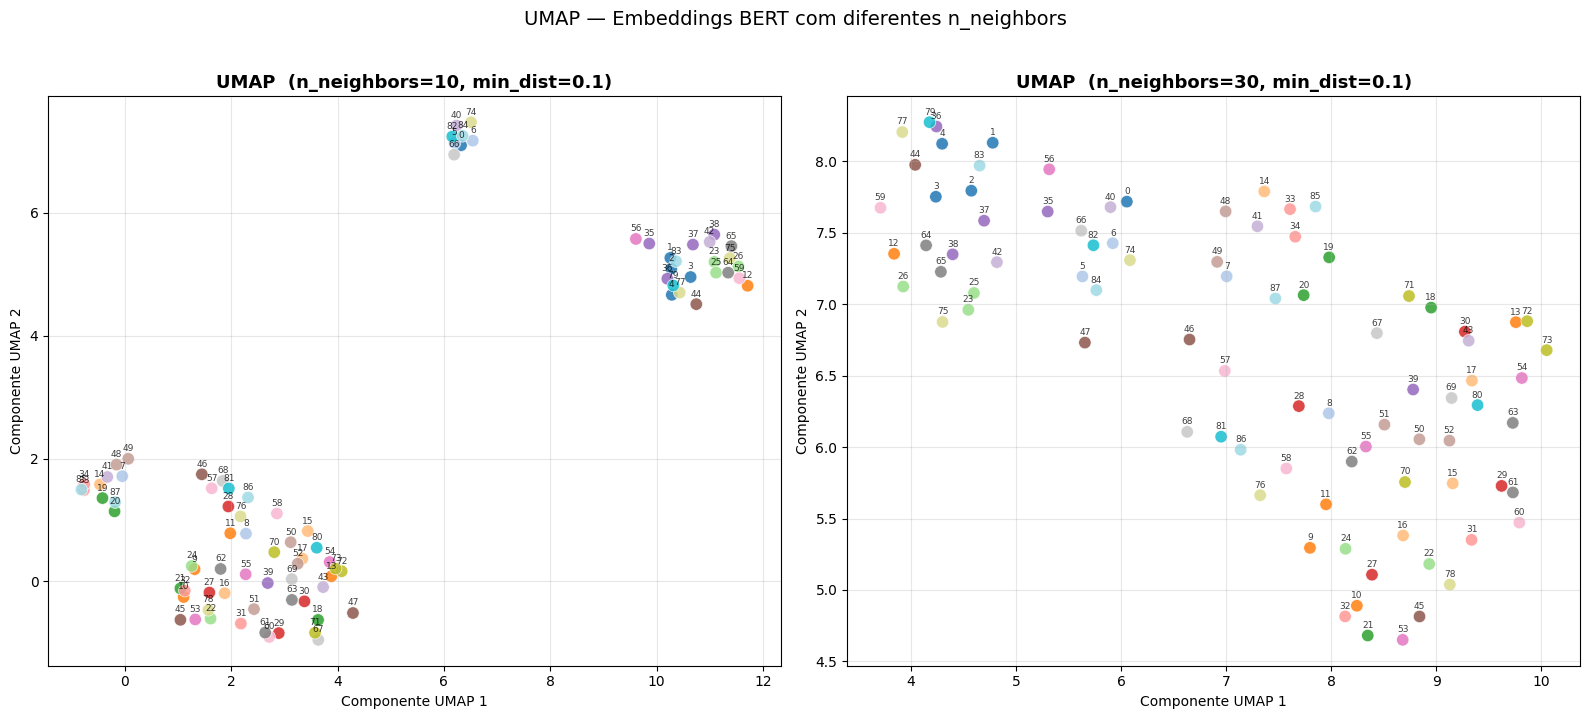

Análise: n_neighbors menor → estrutura local fina; clusters podem fragmentar.
n_neighbors maior → visão mais global; separação inter-cluster mais nítida.
Diferente do t-SNE, o UMAP tende a preservar distâncias relativas entre clusters.


In [6]:
# ── UMAP: preservação de estrutura local e global ───────────────────────────
# Requer: pip install umap-learn
# Testamos dois valores de n_neighbors para comparar a escala de vizinhança.

import umap

neighbor_values = [10, 30]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, n_neigh in zip(axes, neighbor_values):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neigh,
        min_dist=0.1,
        metric='cosine',    # distância coseno é natural para embeddings de texto
        random_state=42
    )
    X_umap_tmp = reducer.fit_transform(X_norm)
    ax.scatter(X_umap_tmp[:, 0], X_umap_tmp[:, 1],
               c=np.arange(len(sentences)), cmap='tab20',
               s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
    for i, (x, y) in enumerate(X_umap_tmp):
        ax.annotate(str(i), (x, y), fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points', alpha=0.75)
    ax.set_title(f'UMAP  (n_neighbors={n_neigh}, min_dist=0.1)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Componente UMAP 1', fontsize=10)
    ax.set_ylabel('Componente UMAP 2', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('UMAP — Embeddings BERT com diferentes n_neighbors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Versão final (n_neighbors=15) para comparação
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                           metric='cosine', random_state=42)
X_umap_final = reducer_final.fit_transform(X_norm)

print("Análise: n_neighbors menor → estrutura local fina; clusters podem fragmentar.")
print("n_neighbors maior → visão mais global; separação inter-cluster mais nítida.")
print("Diferente do t-SNE, o UMAP tende a preservar distâncias relativas entre clusters.")

## Classificação

Com base nas categorias observadas nos gráficos anteriores, crie uma função simples que receba um texto e classifique-o na categoria mais provável.

**Tarefas:**
- Use os embeddings existentes e os clusters identificados para rotular automaticamente cada texto.  
- Crie uma função `classificar_texto(texto: str)` que:
  1. Gere o embedding do texto.
  2. Calcule a distância para os clusters identificados.
  3. Retorne o nome do cluster mais próximo.

=== Composição dos clusters ===

Cluster 0 — Culinária (14 textos):
  [00] I swap butter for olive oil in many recipes.
  [05] I prefer my coffee with no sugar and a splash of milk.
  [06] The recipe for pasta carbonara is simple.
  [35] What is the capital of France?
  [40] I batch-cook grains for quick lunches.
  [46] Sourdough starter needs regular feedings to stay active.
  [47] The stock market experienced a drop today.
  [56] What country contains the city of Kyoto?
  [57] Stir-frying requires high heat and constant movement.
  [66] I cook vegetarian meals on weekdays to simplify planning.
  [68] Sous-vide delivers precise temperature control.
  [74] Mise en place speeds up weeknight cooking.
  [82] I keep a jar of homemade pesto for pasta.
  [84] I like to cook Italian dishes on Sundays.

Cluster 1 — Finanças / Investimentos (23 textos):
  [08] Alignment techniques reduce harmful outputs.
  [09] Explainable AI highlights salient features for decisions.
  [10] Transformer models 

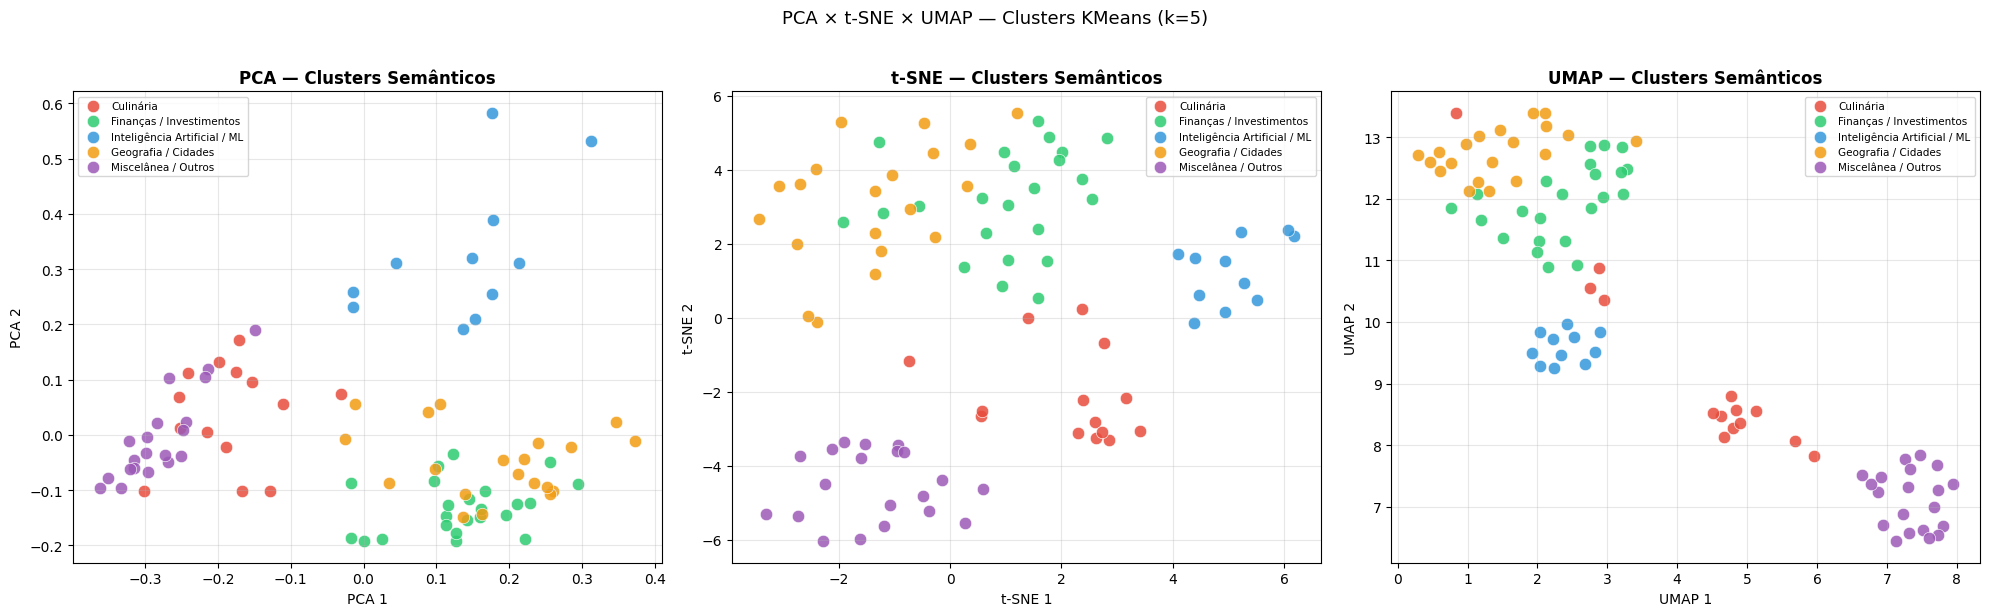

=== Teste: classificar_texto() ===

Texto : Brasília is the capital city of Brazil.
Classe: Miscelânea / Outros

Texto : Gradient descent optimizes neural network weights.
Classe: Finanças / Investimentos

Texto : The soufflé must be served immediately after baking.
Classe: Culinária

Texto : Dividend reinvestment compounds wealth over decades.
Classe: Geografia / Cidades

Texto : The Amazon rainforest covers most of northern Brazil.
Classe: Miscelânea / Outros



In [7]:
# ── Clustering com KMeans para nomear categorias ────────────────────────────

N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_norm)

# Nomes atribuídos manualmente após inspeção visual dos grupos
CLUSTER_NAMES = {
    0: 'Culinária',
    1: 'Finanças / Investimentos',
    2: 'Inteligência Artificial / ML',
    3: 'Geografia / Cidades',
    4: 'Miscelânea / Outros'
}

print("=== Composição dos clusters ===\n")
for c in range(N_CLUSTERS):
    indices = np.where(cluster_labels == c)[0]
    print(f"Cluster {c} — {CLUSTER_NAMES[c]} ({len(indices)} textos):")
    for idx in indices:
        print(f"  [{idx:02d}] {sentences[idx]}")
    print()

# ── Visualização comparativa com rótulos de cluster ──────────────────────────
PALETTE = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (X_2d, title) in zip(axes, [
    (X_pca,        'PCA'),
    (X_tsne_final, 't-SNE'),
    (X_umap_final, 'UMAP'),
]):
    for c in range(N_CLUSTERS):
        mask = cluster_labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=PALETTE[c], label=CLUSTER_NAMES[c],
                   s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.set_title(f'{title} — Clusters Semânticos', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{title} 1', fontsize=10)
    ax.set_ylabel(f'{title} 2', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7.5, loc='best')

plt.suptitle('PCA × t-SNE × UMAP — Clusters KMeans (k=5)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Função de classificação ───────────────────────────────────────────────────

def classificar_texto(texto: str) -> str:
    """
    Classifica um texto na categoria semântica mais provável.

    Pipeline:
      1. Gera o embedding BERT do texto de entrada.
      2. Normaliza o vetor (L2).
      3. Calcula a distância euclidiana para cada centróide KMeans.
      4. Retorna o nome do cluster cujo centróide está mais próximo.

    Parâmetros
    ----------
    texto : str  —  Sentença ou parágrafo a classificar.

    Retorna
    -------
    str  —  Nome da categoria semântica mais próxima.
    """
    emb = get_bert_embedding([texto], tokenizer, model)
    emb_norm = normalize(emb, norm='l2')
    distances = np.linalg.norm(kmeans.cluster_centers_ - emb_norm, axis=1)
    return CLUSTER_NAMES[int(np.argmin(distances))]


# ── Testes ────────────────────────────────────────────────────────────────────
test_sentences = [
    "Brasília is the capital city of Brazil.",
    "Gradient descent optimizes neural network weights.",
    "The soufflé must be served immediately after baking.",
    "Dividend reinvestment compounds wealth over decades.",
    "The Amazon rainforest covers most of northern Brazil.",
]

print("=== Teste: classificar_texto() ===\n")
for s in test_sentences:
    print(f"Texto : {s}")
    print(f"Classe: {classificar_texto(s)}\n")